# Modelo LDR
$$G=AE^\gamma$$

- $G$: conductancia
- $E$: idealmente iluminancia. En este caso es la intensidad relativa de cada LED
    - $E = c \in [0,255]$
- $A,\,\gamma$: variables

# Resolución por minimización de cuadrados

Se toman $n$ medidas de la conductancia $G$ a intensidades $c$ conocidas para cada color.

$$
Y = 
\begin{bmatrix}
G_1 \\
G_2 \\
\vdots \\
G_N
\end{bmatrix}
\qquad
A = 
\begin{bmatrix}
1 & \ln(c_1) \\
1 & \ln(c_2) \\
1 & \ln(c_N) \\
\end{bmatrix}
\qquad
\beta = 
\begin{bmatrix}
\alpha_1 \\
\alpha_2 \\
\vdots \\
\alpha_M \\
\end{bmatrix}
$$


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
Vref = 3.3
Vdd = 5

In [4]:
dfR = pd.read_json("measurements_R.json").set_index("index")
dfR = dfR.drop("data", axis="columns")
dfR = dfR.rename(columns={"mean": "adc"})
dfR.tail()

,channel,intensity,adc,Rf
index,,,,
16,R,96,2939.500,1
17,R,123,2732.925,1
18,R,157,2536.975,1
19,R,200,2329.800,1
20,R,255,2114.225,1


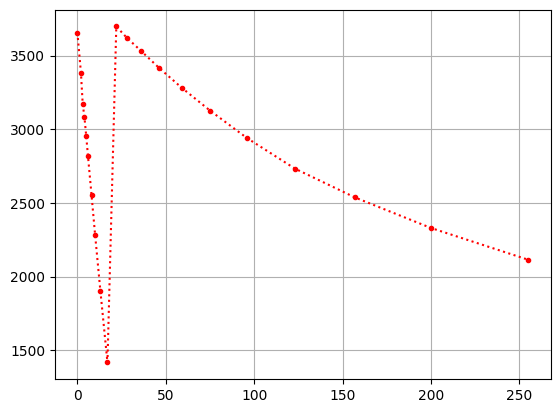

In [5]:
plt.plot("intensity", "adc", data=dfR, marker=".", linestyle="dotted", color="red")
plt.grid()

In [8]:
dfR["Vo"] = dfR["adc"] * Vref / 4095 
dfR.head()

,channel,intensity,adc,Rf,Vo
index,,,,,
0,R,0,3656.350,10,2.946509
1,R,2,3384.375,10,2.727335
2,R,3,3171.600,10,2.555868
3,R,4,3080.825,10,2.482716
4,R,5,2952.850,10,2.379586


In [9]:
dfR["G"] = (Vref - dfR["Vo"]) / (dfR["Rf"]*(Vdd-Vref))
dfR.head()

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
0,R,0,3656.350,10,2.946509,0.020794
1,R,2,3384.375,10,2.727335,0.033686
2,R,3,3171.600,10,2.555868,0.043772
3,R,4,3080.825,10,2.482716,0.048076
4,R,5,2952.850,10,2.379586,0.054142


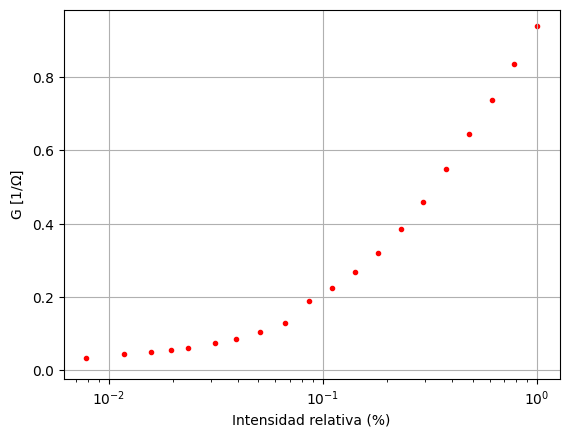

In [15]:
plt.scatter(dfR["intensity"]/255, dfR["G"], marker=".", color="red")
plt.xscale('log')
plt.ylabel(r"G $[1/\Omega]$")
plt.xlabel("Intensidad relativa (%)")
plt.grid()

In [16]:
# least squares
# b = Ax
b, c = (
    np.log(dfR.loc[dfR["intensity"] > 0, "G"]),
    dfR.loc[dfR["intensity"] > 0, "intensity"]
)

A = np.column_stack((np.ones(len(c)), np.log(c)))
A.shape

(20, 2)

In [17]:
x = np.linalg.lstsq(A, b)[0]
x

array([-4.04437444,  0.74035005])

In [18]:
Ka_R = np.exp(x[0])
gamma_R = x[1]

Ka_R, gamma_R

(np.float64(0.017520661514480458), np.float64(0.7403500535910903))

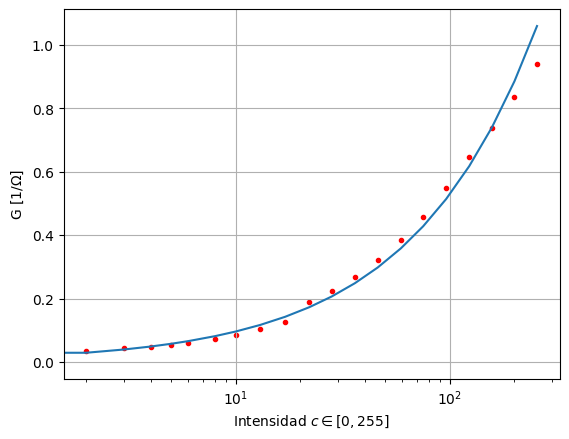

In [23]:
plt.scatter(dfR["intensity"], dfR["G"], marker=".", color="red")
plt.xscale('log')

plt.semilogx(dfR["intensity"], Ka_R*np.pow(dfR["intensity"], gamma_R))

plt.ylabel(r"G $[1/\Omega]$")
plt.xlabel(r"Intensidad $c \in [0,255]$")
plt.grid()

In [24]:
dfR

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
0,R,0,3656.350,10,2.946509,0.020794
1,R,2,3384.375,10,2.727335,0.033686
2,R,3,3171.600,10,2.555868,0.043772
3,R,4,3080.825,10,2.482716,0.048076
4,R,5,2952.850,10,2.379586,0.054142
5,R,6,2816.875,10,2.270009,0.060588
6,R,8,2552.350,10,2.056839,0.073127
7,R,10,2285.700,10,1.841956,0.085767
8,R,13,1903.350,10,1.533835,0.103892


In [268]:
dfG = pd.read_json("measurements_G.json").set_index("index")
dfG = dfG.drop("data", axis="columns")
dfG = dfG.rename(columns={"mean": "adc"})
dfG

,channel,intensity,adc,Rf
index,,,,
0,G,0,3674.800,10
1,G,2,3589.075,10
2,G,3,3538.575,10
3,G,4,3490.125,10
4,G,5,3428.775,10
5,G,6,3357.850,10
6,G,8,3225.750,10
7,G,10,3161.700,10
8,G,13,3091.900,10


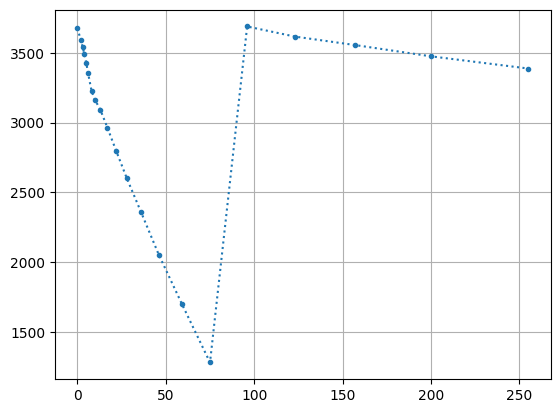

In [264]:
plt.plot("intensity", "adc", data=dfG, marker=".", linestyle="dotted")
plt.grid()

In [ ]:
dfG["Vo"] = dfG["adc"] * Vref / 4095 
dfG["G"] = (Vref - dfG["Vo"]) / (dfG["Rf"]*(Vdd-Vref))
dfG.tail()

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
0,G,0,3674.800,10,2.961377,0.019919
1,G,2,3589.075,10,2.892295,0.023983
2,G,3,3538.575,10,2.851599,0.026377
3,G,4,3490.125,10,2.812555,0.028673
4,G,5,3428.775,10,2.763115,0.031581


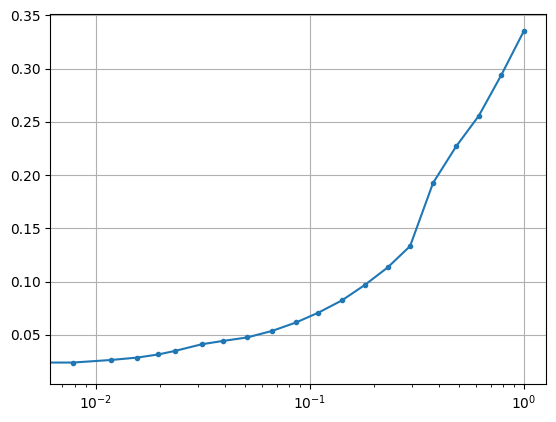

In [267]:
plt.semilogx(dfG["intensity"]/255, dfG["G"], marker=".")
plt.grid()